# PAMAP2 Dataset
## Data Loading and Exploratory Data Analysis (EDA)

This notebook loads the PAMAP2 Physical Activity Monitoring dataset, merges all subjects into a single dataframe, and performs exploratory data analysis before preprocessing.

## Dataset Path

In [1]:
import os

DATA_PATH = "/lustre09/project/6081099/reem2005/DATASET/PAMAP2_Dataset/Protocol"

print(os.listdir(DATA_PATH))

['subject108.dat', 'subject101.dat', 'subject106.dat', 'subject107.dat', 'subject109.dat', 'subject103.dat', 'subject104.dat', 'subject105.dat', 'subject102.dat']


In [2]:
import os
os.environ.pop('PIP_PREFIX', None)

import sys
!{sys.executable} -m pip install --no-index --user --ignore-installed torch torchvision torchaudio

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3/torch-2.13.0+computecanada-cp311-cp311-linux_x86_64.whl
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic/torchvision-0.28.0+computecanada-cp311-cp311-linux_x86_64.whl
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3/torchaudio-2.11.0+computecanada-cp311-cp311-linux_x86_64.whl
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/filelock-3.29.3+computecanada-py3-none-any.whl (from torch)
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/typing_extensions-4.16.0+computecanada-py3-none-any.w

In [3]:
import os
os.environ.pop('PIP_PREFIX', None)

import sys
!{sys.executable} -m pip install --no-index --user einops

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


## Load All Subjects

In [4]:
import pandas as pd
import os

# =========================
# PAMAP2 official columns
# =========================

column_names = [
    'timestamp',
    'activityID',
    'heart_rate',

    'hand_temperature',
    'hand_acc16_x',
    'hand_acc16_y',
    'hand_acc16_z',
    'hand_acc6_x',
    'hand_acc6_y',
    'hand_acc6_z',
    'hand_gyro_x',
    'hand_gyro_y',
    'hand_gyro_z',
    'hand_mag_x',
    'hand_mag_y',
    'hand_mag_z',
    'hand_orientation_1',
    'hand_orientation_2',
    'hand_orientation_3',
    'hand_orientation_4',

    'chest_temperature',
    'chest_acc16_x',
    'chest_acc16_y',
    'chest_acc16_z',
    'chest_acc6_x',
    'chest_acc6_y',
    'chest_acc6_z',
    'chest_gyro_x',
    'chest_gyro_y',
    'chest_gyro_z',
    'chest_mag_x',
    'chest_mag_y',
    'chest_mag_z',
    'chest_orientation_1',
    'chest_orientation_2',
    'chest_orientation_3',
    'chest_orientation_4',

    'ankle_temperature',
    'ankle_acc16_x',
    'ankle_acc16_y',
    'ankle_acc16_z',
    'ankle_acc6_x',
    'ankle_acc6_y',
    'ankle_acc6_z',
    'ankle_gyro_x',
    'ankle_gyro_y',
    'ankle_gyro_z',
    'ankle_mag_x',
    'ankle_mag_y',
    'ankle_mag_z',
    'ankle_orientation_1',
    'ankle_orientation_2',
    'ankle_orientation_3',
    'ankle_orientation_4'
]

# =========================
# Path
# =========================
path = "/lustre09/project/6081099/reem2005/DATASET/PAMAP2_Dataset/Protocol"

# =========================
# Load all subjects
# =========================

all_data = []

for file in sorted(os.listdir(path)):

    if file.endswith(".dat"):

        subject = int(
            file.replace("subject", "")
                .replace(".dat", "")
        )

        file_path = os.path.join(path, file)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            names=column_names
        )

        df["subject"] = subject

        all_data.append(df)

# =========================
# Merge all subjects
# =========================

data = pd.concat(
    all_data,
    ignore_index=True
)

print("Shape:", data.shape)

print("\nNumber of columns:", len(data.columns))

print("\nFirst rows:")
display(data.head())

print("\nColumns:")
print(data.columns.tolist())

Shape: (2872533, 55)

Number of columns: 55

First rows:


,timestamp,activityID,heart_rate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orientation_1,ankle_orientation_2,ankle_orientation_3,ankle_orientation_4,subject
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,...,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,101
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,101
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,...,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,101
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,...,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0,101
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,...,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0,101



Columns:
['timestamp', 'activityID', 'heart_rate', 'hand_temperature', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'hand_orientation_1', 'hand_orientation_2', 'hand_orientation_3', 'hand_orientation_4', 'chest_temperature', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'chest_orientation_1', 'chest_orientation_2', 'chest_orientation_3', 'chest_orientation_4', 'ankle_temperature', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z', 'ankle_orientation_1', 'ankle_orientation_2', 'ankle_orientation_3', 'ankle_orientation_4', 'subject']


## Dataset Overview

In [5]:
print(data.shape)

display(data.head())

print(data.columns.tolist())

(2872533, 55)


,timestamp,activityID,heart_rate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orientation_1,ankle_orientation_2,ankle_orientation_3,ankle_orientation_4,subject
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,...,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,101
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,101
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,...,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,101
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,...,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0,101
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,...,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0,101


['timestamp', 'activityID', 'heart_rate', 'hand_temperature', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'hand_orientation_1', 'hand_orientation_2', 'hand_orientation_3', 'hand_orientation_4', 'chest_temperature', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'chest_orientation_1', 'chest_orientation_2', 'chest_orientation_3', 'chest_orientation_4', 'ankle_temperature', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z', 'ankle_orientation_1', 'ankle_orientation_2', 'ankle_orientation_3', 'ankle_orientation_4', 'subject']


## Number of Subjects

In [6]:
print(data["subject"].nunique())

print(sorted(data["subject"].unique()))

data["subject"].value_counts()

9
[np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109)]


subject
102    447000
108    408031
101    376417
105    374783
106    361817
104    329576
107    313599
103    252833
109      8477
Name: count, dtype: int64

## Samples per Subject

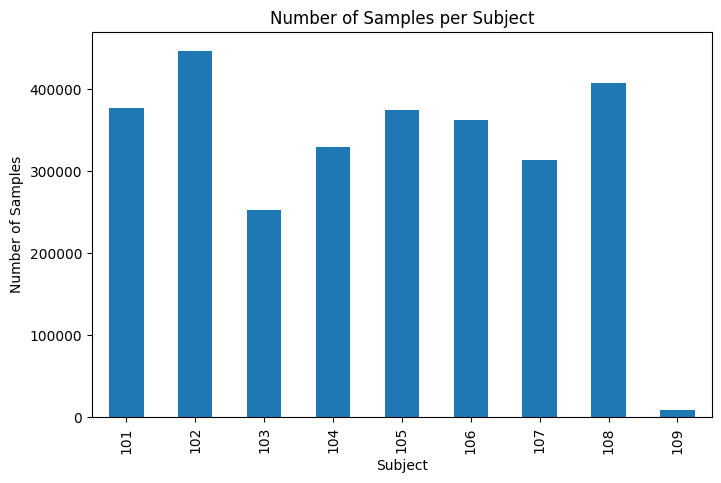

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

data["subject"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Samples per Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Samples")

plt.show()

## Activity Distribution

This section shows the distribution of activity labels across the entire dataset.

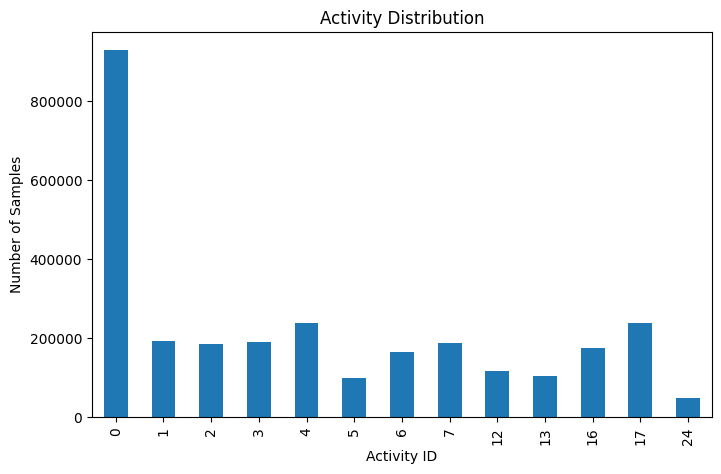

In [9]:
data["activityID"].value_counts().sort_index()
plt.figure(figsize=(8,5))

data["activityID"].value_counts().sort_index().plot(kind="bar")

plt.title("Activity Distribution")
plt.xlabel("Activity ID")
plt.ylabel("Number of Samples")

plt.show()

## Activity Distribution per Subject

The following table summarizes how activity samples are distributed for each participant.

In [10]:
activity_by_subject = pd.crosstab(
    data["subject"],
    data["activityID"]
)

activity_by_subject

activityID,0,1,2,3,4,5,6,7,12,13,16,17,24
subject,,,,,,,,,,,,,
101,126460,27187,23480,21717,22253,21265,23575,20265,15890,14899,22941,23573,12912
102,183651,23430,22345,25576,32533,9238,25108,29739,17342,15213,20683,28880,13262
103,78495,22044,28761,20533,29036,0,0,0,10389,15275,20325,27975,0
104,98155,23047,25492,24706,31932,1,22699,27533,16694,14285,20037,24995,0
105,102341,23699,26864,22132,32033,24646,24577,26271,14281,12727,24445,33034,7733
106,111721,23340,23041,24356,25721,22825,20486,26686,13291,11272,21078,37744,256
107,80823,25611,12282,25751,33720,3692,22680,28725,17646,11618,21552,29499,0
108,145929,24165,22923,25160,31533,16532,25475,28888,11683,9655,24292,32990,8806
109,2086,0,0,0,0,0,0,0,0,0,0,0,6391


## Activity Distribution Across Subjects

The following heatmap illustrates the distribution of activity samples for each participant.


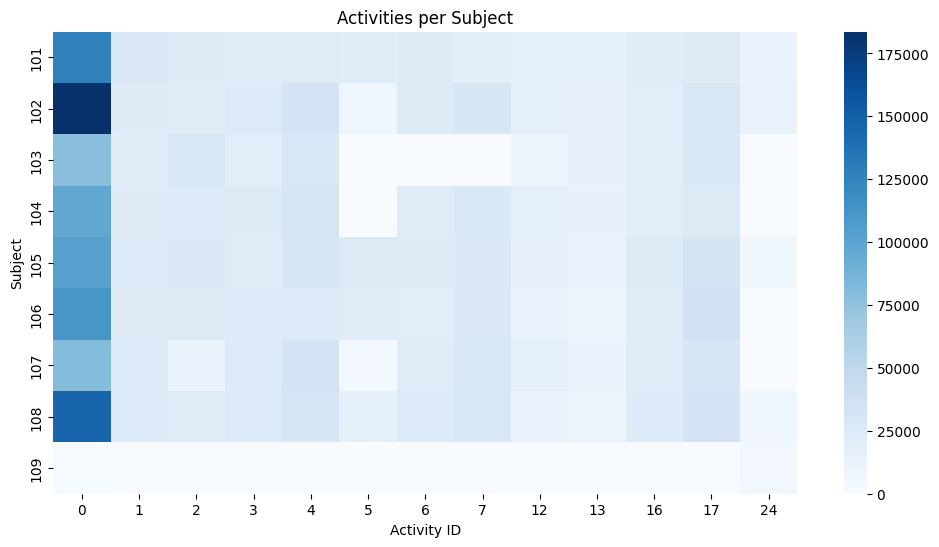

In [11]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    activity_by_subject,
    cmap="Blues"
)

plt.title("Activities per Subject")

plt.xlabel("Activity ID")
plt.ylabel("Subject")

plt.show()

## Missing Values Analysis

This section identifies missing values in the PAMAP2 dataset before preprocessing.

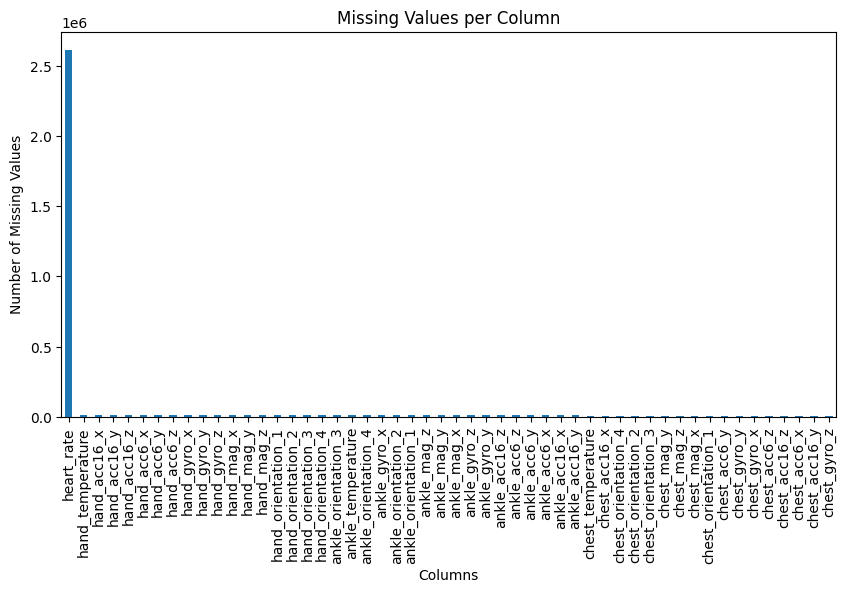

In [12]:
missing = data.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing
plt.figure(figsize=(10,5))

missing.plot(kind="bar")

plt.title("Missing Values per Column")

plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.show()

## Sensor Statistics

Basic descriptive statistics for one accelerometer sensor.

In [13]:
data[
    [
        "hand_acc16_x",
        "hand_acc16_y",
        "hand_acc16_z"
    ]
].describe()

,hand_acc16_x,hand_acc16_y,hand_acc16_z
count,2.859392e+06,2.859392e+06,2.859392e+06
mean,-4.960786e+00,3.587758e+00,3.168417e+00
std,5.985029e+00,6.277838e+00,3.843923e+00
min,-1.453670e+02,-1.043010e+02,-1.014520e+02
25%,-9.028420e+00,1.290268e+00,9.685818e-01
50%,-5.788145e+00,3.570830e+00,2.958415e+00
75%,-7.829420e-01,6.602720e+00,6.002930e+00
max,6.285960e+01,1.556990e+02,1.577600e+02


## Sensor Data Distribution

Boxplots are used to identify possible outliers in the accelerometer measurements.

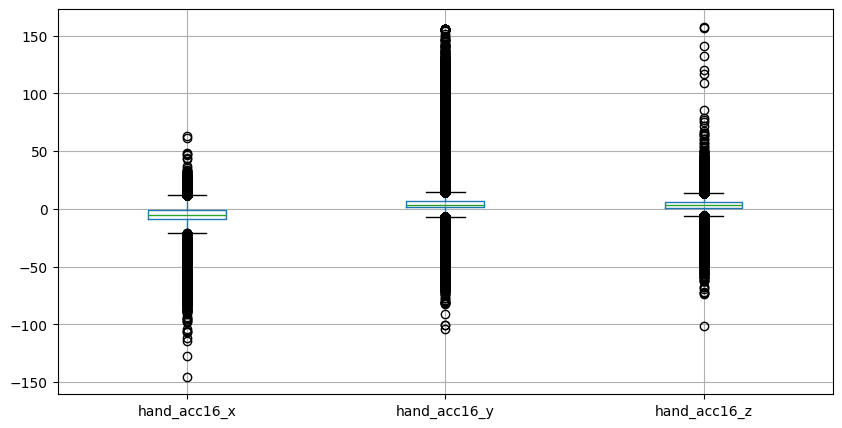

In [14]:
plt.figure(figsize=(10,5))

data[
    [
        "hand_acc16_x",
        "hand_acc16_y",
        "hand_acc16_z"
    ]
].boxplot()

plt.show()

## Remove Transient Activity (Activity ID = 0)

Activity ID 0 corresponds to transient movements and is removed before model training.

In [15]:
print("Before:", data.shape)

data = data[data["activityID"] != 0]

print("After:", data.shape)

Before: (2872533, 55)
After: (1942872, 55)


In [16]:
missing_percent = (
    data.isnull().sum() / len(data)
) * 100

missing_percent[
    missing_percent > 0
].sort_values(ascending=False)

heart_rate             90.868776
hand_temperature        0.572554
hand_acc16_x            0.572554
hand_acc16_y            0.572554
hand_acc16_z            0.572554
hand_acc6_x             0.572554
hand_acc6_y             0.572554
hand_acc6_z             0.572554
hand_gyro_x             0.572554
hand_gyro_y             0.572554
hand_gyro_z             0.572554
hand_mag_x              0.572554
hand_mag_y              0.572554
hand_mag_z              0.572554
hand_orientation_1      0.572554
hand_orientation_2      0.572554
hand_orientation_3      0.572554
hand_orientation_4      0.572554
ankle_orientation_3     0.437857
ankle_temperature       0.437857
ankle_orientation_4     0.437857
ankle_gyro_x            0.437857
ankle_orientation_2     0.437857
ankle_orientation_1     0.437857
ankle_mag_z             0.437857
ankle_mag_y             0.437857
ankle_mag_x             0.437857
ankle_gyro_z            0.437857
ankle_gyro_y            0.437857
ankle_acc16_z           0.437857
ankle_acc6

## Remove Orientation Features

Orientation features contain a large number of missing values and are excluded from further analysis.

In [17]:
orientation_cols = [
    col for col in data.columns
    if "orientation" in col
]

print(
    "Orientation columns:",
    len(orientation_cols)
)

data = data.drop(columns=orientation_cols)

print("New shape:", data.shape)

Orientation columns: 12
New shape: (1942872, 43)


## Remove Heart Rate Feature

Heart rate contains many missing values and is excluded from the analysis.

In [18]:
data = data.drop(columns=["heart_rate"])

print(data.shape)

(1942872, 42)


## Remove Subject 109

Subject 109 contains incomplete recordings and is removed from the dataset.

In [19]:
data = data[
    data["subject"] != 109
].copy()

print(data["subject"].unique())

print(data.shape)

[101 102 103 104 105 106 107 108]
(1936481, 42)


## Interpolate Missing Sensor Values

Missing sensor values are interpolated independently for each subject.

In [20]:
import numpy as np

numeric_cols = data.select_dtypes(
    include=[np.number]
).columns.tolist()

numeric_cols.remove("subject")
numeric_cols.remove("activityID")

data[numeric_cols] = (
    data.groupby("subject")[numeric_cols]
        .transform(
            lambda x: x.interpolate().ffill().bfill()
        )
)

print(
    "Remaining NaNs:",
    data.isnull().sum().sum()
)

print(data.shape)

Remaining NaNs: 0
(1936481, 42)


In [21]:
data.isnull().sum().sum()

np.int64(0)

## Activity Distribution After Cleaning

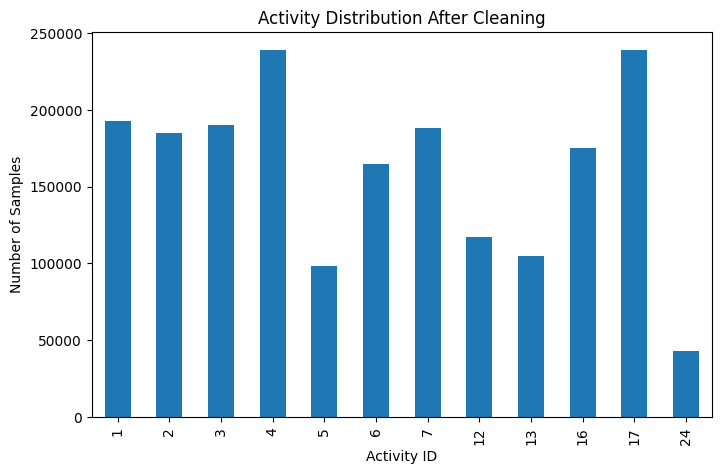

In [22]:
plt.figure(figsize=(8,5))

data["activityID"].value_counts().sort_index().plot(kind="bar")

plt.title("Activity Distribution After Cleaning")
plt.xlabel("Activity ID")
plt.ylabel("Number of Samples")

plt.show()

## Save Preprocessed Dataset

In [23]:
SAVE_PATH = "/lustre09/project/6081099/reem2005/DATASET/pamap2_preprocessed.csv"

data.to_csv(SAVE_PATH, index=False)

print("Dataset saved successfully.")
print("Shape:", data.shape)

Dataset saved successfully.
Shape: (1936481, 42)
